In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
import pickle

In [33]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [34]:
df = sns.load_dataset("taxis")
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [35]:
df.shape

(6433, 14)

In [36]:
df = df[["distance","fare"]]
df

,distance,fare
0,1.60,7.0
1,0.79,5.0
2,1.37,7.5
3,7.70,27.0
4,2.16,9.0
...,...,...
6428,0.75,4.5
6429,18.74,58.0
6430,4.14,16.0
6431,1.12,6.0


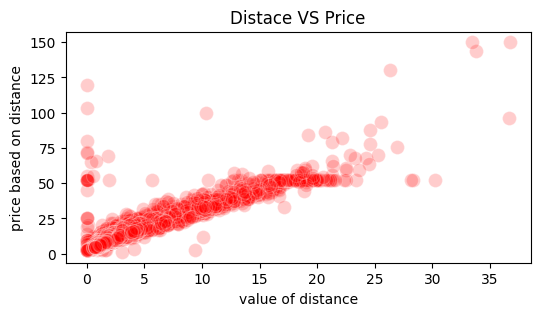

In [37]:
plt.figure(figsize=(6,3))
sns.scatterplot(x=df["distance"]  ,y = df["fare"], color ="r", marker="o", s=100, alpha=.2)
plt.xlabel("value of distance")
plt.ylabel("price based on distance")
plt.title("Distace VS Price")
plt.show()

In [38]:
df.isna()

,distance,fare
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
6428,False,False
6429,False,False
6430,False,False
6431,False,False


In [39]:
df.duplicated().sum()

np.int64(2978)

In [40]:
#outlier removing

In [41]:
Q1 = df["distance"].quantile(0.25)
Q3 =  df["distance"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["distance"] >= lower) & (df["distance"] <= upper)]


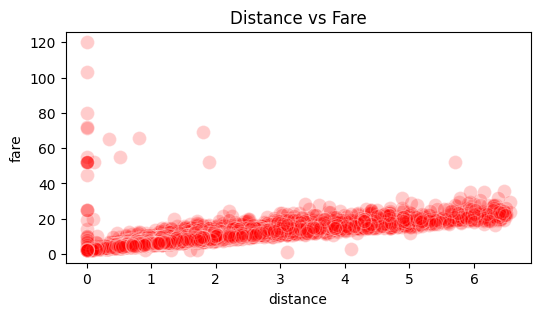

In [42]:
plt.figure(figsize=(6,3))
sns.scatterplot(x=df["distance"]  ,y = df["fare"], color ="r", marker="o", s=100, alpha=.2)
plt.title("Distance vs Fare")
plt.show()

In [43]:
df.duplicated().sum()

np.int64(2945)

In [44]:
df = df.drop_duplicates()

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.head()

,distance,fare
0,1.60,7.0
1,0.79,5.0
2,1.37,7.5
4,2.16,9.0
5,0.49,7.5


In [47]:
df.info()

<class 'pandas.DataFrame'>
Index: 2754 entries, 0 to 6432
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   distance  2754 non-null   float64
 1   fare      2754 non-null   float64
dtypes: float64(2)
memory usage: 64.5 KB


In [48]:
df.describe()

,distance,fare
count,2754.000000,2754.000000
mean,2.433290,12.252222
std,1.531364,6.839011
min,0.000000,1.000000
25%,1.240000,8.000000
50%,2.100000,11.500000
75%,3.400000,15.500000
max,6.550000,120.000000


<Axes: >

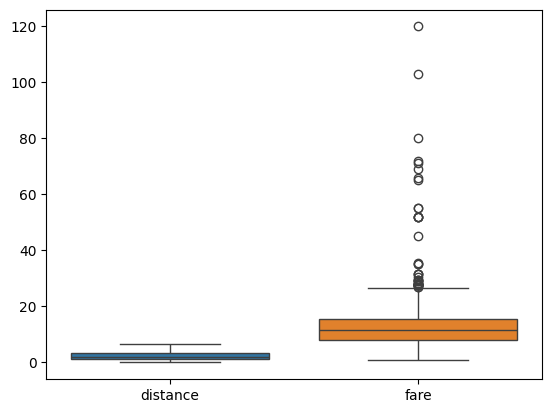

In [49]:
sns.boxplot(df)

In [50]:
df.columns

Index(['distance', 'fare'], dtype='str')

In [51]:
df.shape

(2754, 2)

In [52]:
X = df[["distance"]]
y = df["fare"]


<Axes: >

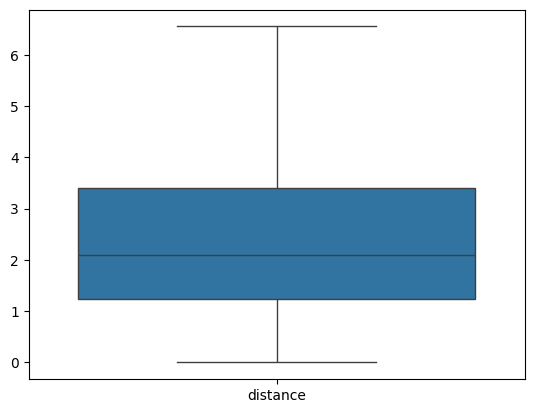

In [53]:
sns.boxplot(X)

In [54]:
#split the dataset

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [56]:
X_train.head(3)


,distance
336,4.08
1242,0.67
2403,5.22


In [57]:
y_train.head(3)

336     14.5
1242     5.5
2403    22.0
Name: fare, dtype: float64

In [58]:
#training the model

In [59]:
model = LinearRegression()
model.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
model.score(X_train, y_train)

0.39054174415289644

In [61]:
model.score(X_test, y_test)

0.3542468726962511

In [62]:
model.predict([[45]])

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([129.83523195])

In [63]:
y_pred = model.predict(X_test)

In [64]:
y_test

6387    18.48
3749     8.50
2082     9.50
2513     4.00
4765     5.50
        ...  
409     13.50
1223     5.00
1133    11.50
772      4.00
909     23.00
Name: fare, Length: 551, dtype: float64

In [65]:
r_sc= r2_score(y_test, y_pred)
r_sc

0.3542468726962511

In [66]:
# cost calculation
mae = mean_absolute_error(y_test, y_pred)
mae

2.363350072384981

In [67]:
mse=  mean_squared_error(y_test, y_pred)
mse

34.3099124485614

In [68]:
#save model

In [70]:
with open("taxi_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [72]:
with open("taxi_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)
loaded_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
